# BMW dataset Analysis
#### We have our model already built and ready for testing on real data. We use the BMW vehicle specs dataset that includes prices of a certain BMW car, sales, car name, and etc. Goal is to test significance of the price as predictor for sales using simple linear regression.

# Data import 
#### We start by importing our data, nothing fancy but we must feed absolute paths so we can run from the project root.


In [21]:
from pathlib import Path
import csv

BASE_PATH = Path().resolve()
DATA_PATH = BASE_PATH / 'bmw_saless.csv'

sales, price = [],[]
try:
    with open(DATA_PATH, newline="") as csvfile:
        data = csv.DictReader(csvfile)
        for row in data:
            price.append(row['Price_USD'])
            sales.append(row['Sales_Volume'])
        print('import successful')
except Exception as e:
    print(f'not working: {e}')



import successful


 Data is represented as a 50,000 x 2 matrix to feed into `LineReg` class

In [22]:
import numpy as np 
data = np.column_stack(
    [np.array(price, dtype=np.float64), 
     np.array(sales, dtype = np.float64)] ) 
data.shape
price

(50000, 2)

# Plotting distribution
#### Lets look at the distribution of prices for each BMW. We will sample a random choice of 10,000 values and seperate them in $n$ bins

(np.float64(74734.7041), np.float64(25905.896307936215))

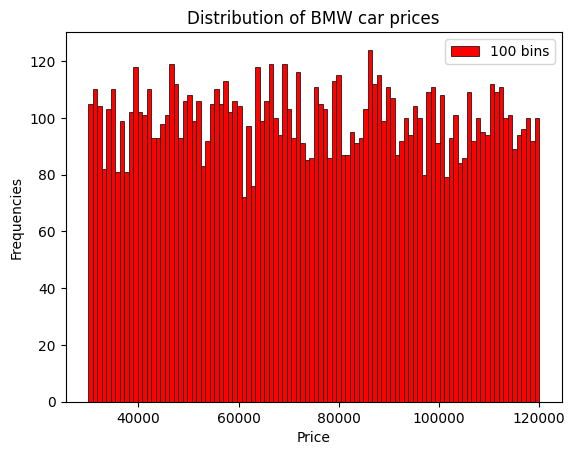

In [76]:
import matplotlib.pyplot as plt

np.random.seed(32131)

samp = np.random.choice(data[:,0], size=10000)
fig, ax1 = plt.subplots()
n_bins = 100
ax1.hist(samp, bins=n_bins, label=f'{n_bins} bins', color='red', linewidth=0.5,edgecolor='black')
ax1.set_ylabel('Frequencies')
ax1.set_xlabel('Price')
ax1.set_title('Distribution of BMW car prices')
ax1.legend()

np.mean(samp), np.std(samp)

# Plotting BMW car sales against price
#### A great way to diagnose the data even before testing, we can catch some early indications of a relationship of the two variables.

Text(0.5, 1.0, 'BMW car Sales plotted against  Price')

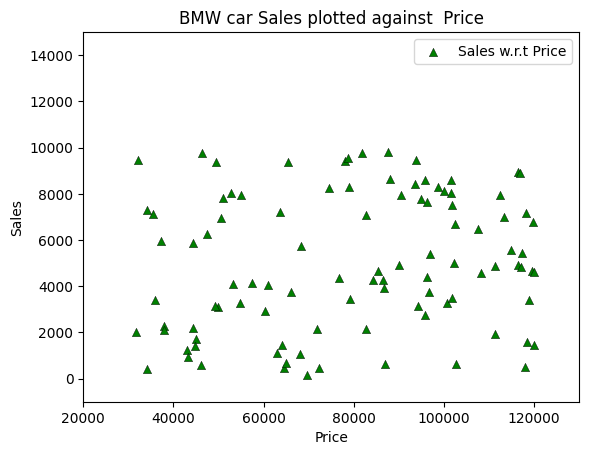

In [75]:
fig, ax2 = plt.subplots()
ax2.scatter(data[:,0][:100], data[:,1][:100], label='Sales w.r.t Price', color='green', marker='^',
           edgecolor='black',linewidth=0.3)
ax2.legend()
ax2.set_ylabel('Sales')
ax2.set_xlabel('Price')
ax2.set_ylim(-1000,15000)
ax2.set_xlim(20000,130000)
ax2.set_title('BMW car Sales plotted against  Price')




